In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import warnings
from pathlib import Path
import os
import matplotlib.dates as mdates

In [9]:
# Plot style
plt.rcParams.update({
    "figure.dpi":        150,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "legend.fontsize":   9,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})


In [10]:
base_path = Path(os.getcwd())

CSV_PATH  = base_path / r"..\..\Data\Raw\GME_MGP_NORD_2005_2026.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["datetime", "date"])
df["date"] = pd.to_datetime(df["date"])
 
# Derived time features
df["year"]    = df["datetime"].dt.year
df["month"]   = df["datetime"].dt.month
df["weekday"] = df["datetime"].dt.dayofweek   # 0=Mon, 6=Sun
df["quarter"] = df["datetime"].dt.quarter
df["is_weekend"] = df["weekday"].isin([5, 6])
 
# Month and weekday labels
MONTH_LABELS   = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
WEEKDAY_LABELS = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
 
print("Dataset loaded.")
print(f"  Shape        : {df.shape}")
print(f"  Date range   : {df['datetime'].min()}  →  {df['datetime'].max()}")
print(f"  Columns      : {list(df.columns)}")
df.head()


Dataset loaded.
  Shape        : (186003, 11)
  Date range   : 2005-01-01 00:00:00  →  2026-03-22 23:00:00
  Columns      : ['datetime', 'date', 'hour', 'price_NORD_EURMWh', 'price_PUN_EURMWh', 'mercato', 'year', 'month', 'weekday', 'quarter', 'is_weekend']


,datetime,date,hour,price_NORD_EURMWh,price_PUN_EURMWh,mercato,year,month,weekday,quarter,is_weekend
0,2005-01-01 00:00:00,2005-01-01,0,27.4,27.650421,MGP,2005,1,5,1,True
1,2005-01-01 01:00:00,2005-01-01,1,23.7,24.088555,MGP,2005,1,5,1,True
2,2005-01-01 02:00:00,2005-01-01,2,24.4,24.499444,MGP,2005,1,5,1,True
3,2005-01-01 03:00:00,2005-01-01,3,23.5,23.960878,MGP,2005,1,5,1,True
4,2005-01-01 04:00:00,2005-01-01,4,24.4,24.467464,MGP,2005,1,5,1,True


In [11]:
print("═" * 60)
print("  DATA QUALITY REPORT")
print("═" * 60)
 
total_hours = len(df)
date_range  = pd.date_range(df["datetime"].min(), df["datetime"].max(), freq="h")
expected_h  = len(date_range)
missing_h   = expected_h - total_hours
 
print(f"\n  Expected hourly records  : {expected_h:>10,}")
print(f"  Actual records           : {total_hours:>10,}")
print(f"  Missing hours (gaps)     : {missing_h:>10,}  ({missing_h/expected_h*100:.2f}%)")
 
print(f"\n  NORD price — NaN         : {df['price_NORD_EURMWh'].isna().sum():>10,}")
print(f"  PUN price  — NaN         : {df['price_PUN_EURMWh'].isna().sum():>10,}")
 
print(f"\n  NORD price — zero values : {(df['price_NORD_EURMWh'] == 0).sum():>10,}")
print(f"  NORD price — negative    : {(df['price_NORD_EURMWh'] < 0).sum():>10,}")
print(f"  NORD price — > 500 €/MWh : {(df['price_NORD_EURMWh'] > 500).sum():>10,}")
 
print("\n  Descriptive statistics — NORD price (€/MWh)")
print(df["price_NORD_EURMWh"].describe().rename({
    "count":"count","mean":"mean","std":"std","min":"min",
    "25%":"P25","50%":"P50","75%":"P75","max":"max"}).to_string())
print("═" * 60)
 

════════════════════════════════════════════════════════════
  DATA QUALITY REPORT
════════════════════════════════════════════════════════════

  Expected hourly records  :    186,024
  Actual records           :    186,003
  Missing hours (gaps)     :         21  (0.01%)

  NORD price — NaN         :          0
  PUN price  — NaN         :         96

  NORD price — zero values :         33
  NORD price — negative    :          0
  NORD price — > 500 €/MWh :        891

  Descriptive statistics — NORD price (€/MWh)
count    186003.000000
mean         83.594646
std          69.813980
min           0.000000
P25          47.700000
P50          65.000000
P75          95.000000
max         871.000000
════════════════════════════════════════════════════════════


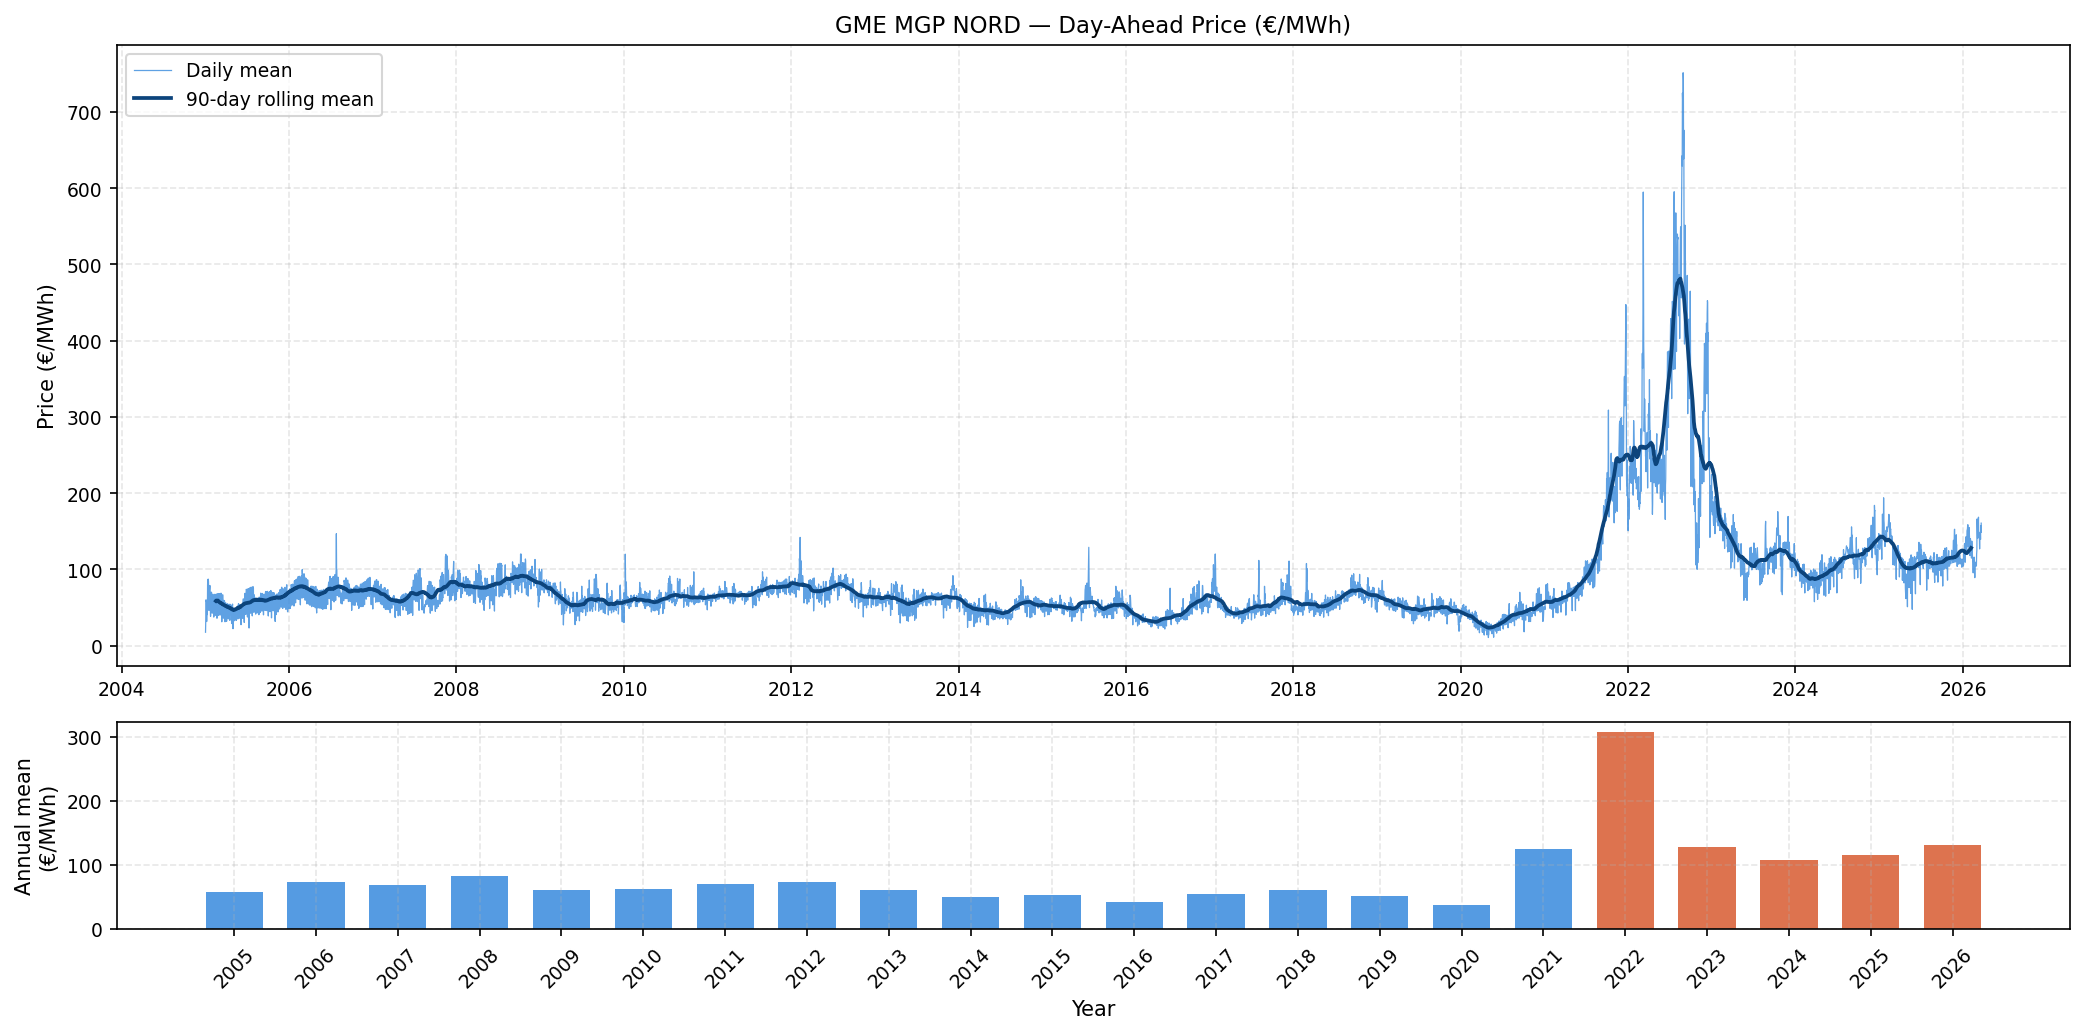

[Fig 1 saved]


In [12]:
df_daily = df.groupby("date")["price_NORD_EURMWh"].mean().reset_index()
df_daily.columns = ["date", "price_daily_mean"]
 
df_annual = df.groupby("year")["price_NORD_EURMWh"].mean().reset_index()
df_annual.columns = ["year", "price_annual_mean"]
 
fig, axes = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={"height_ratios": [3, 1]})
 
# Daily mean series
ax = axes[0]
ax.plot(df_daily["date"], df_daily["price_daily_mean"],
        color="#378ADD", linewidth=0.6, alpha=0.8, label="Daily mean")
# 90-day rolling average
roll = df_daily.set_index("date")["price_daily_mean"].rolling(90, center=True).mean()
ax.plot(roll.index, roll.values, color="#0C447C", linewidth=1.8, label="90-day rolling mean")
ax.set_title("GME MGP NORD — Day-Ahead Price (€/MWh)", fontweight="500")
ax.set_ylabel("Price (€/MWh)")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper left")
 
# Annual mean bar
ax2 = axes[1]
colors = ["#378ADD" if y < 2022 else "#D85A30" for y in df_annual["year"]]
ax2.bar(df_annual["year"], df_annual["price_annual_mean"], color=colors, width=0.7, alpha=0.85)
ax2.set_ylabel("Annual mean\n(€/MWh)")
ax2.set_xlabel("Year")
ax2.set_xticks(df_annual["year"])
ax2.tick_params(axis="x", rotation=45)
 
plt.tight_layout()
plt.show()
print("[Fig 1 saved]")

C:\Users\LucasMonero\AppData\Local\Temp\ipykernel_34628\2148788512.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_list, labels=years, patch_artist=True,


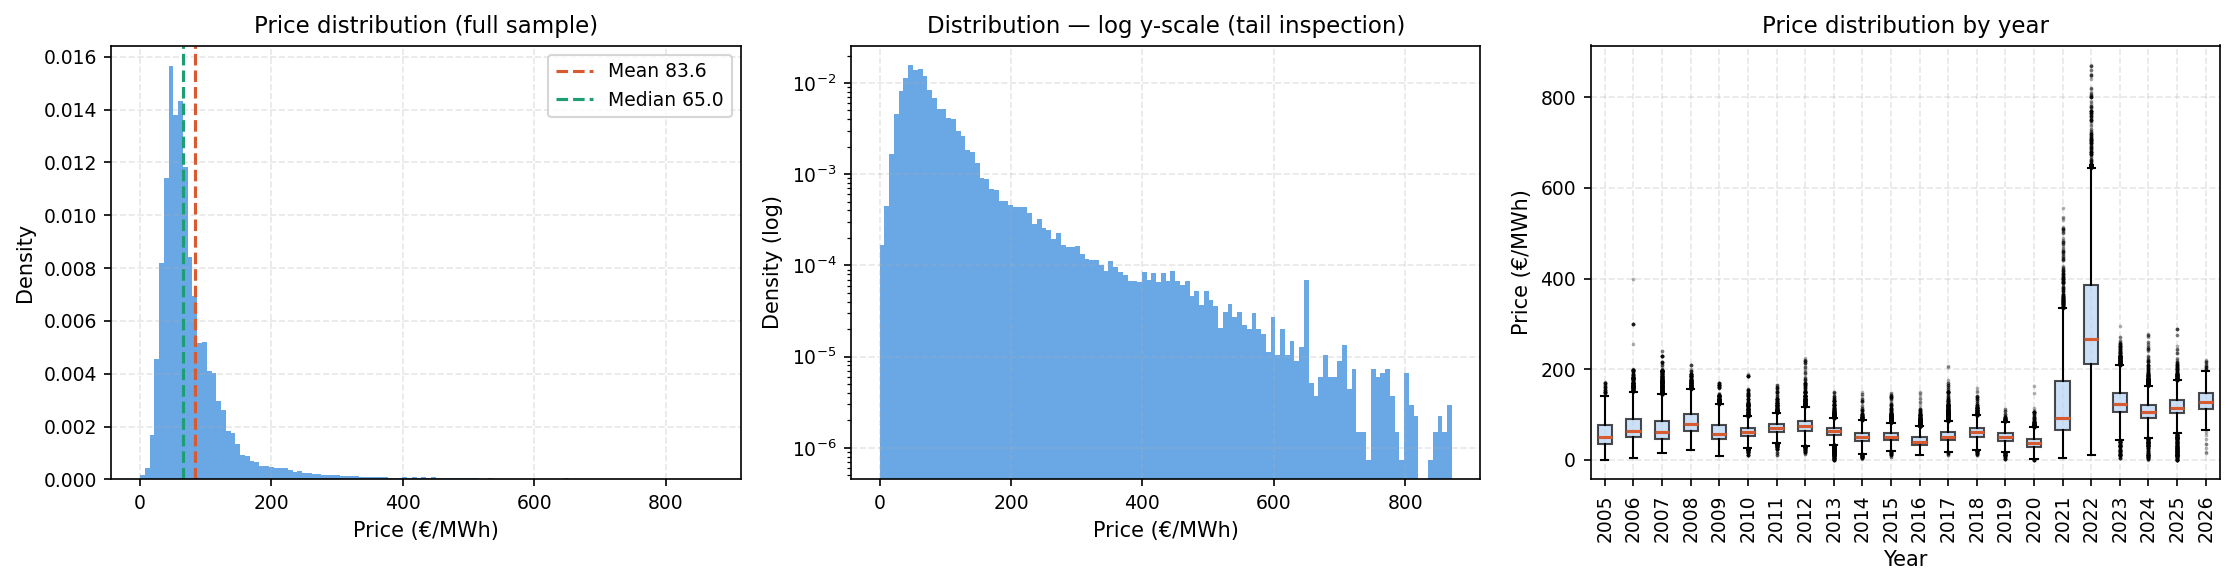

[Fig 2 saved]


In [13]:
price = df["price_NORD_EURMWh"].dropna()
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
# Histogram
ax = axes[0]
ax.hist(price, bins=120, color="#378ADD", alpha=0.75, edgecolor="none", density=True)
ax.axvline(price.mean(),   color="#D85A30", linewidth=1.5, linestyle="--", label=f"Mean {price.mean():.1f}")
ax.axvline(price.median(), color="#1D9E75", linewidth=1.5, linestyle="--", label=f"Median {price.median():.1f}")
ax.set_title("Price distribution (full sample)")
ax.set_xlabel("Price (€/MWh)")
ax.set_ylabel("Density")
ax.legend()
 
# Log-scale histogram to inspect tail
ax = axes[1]
ax.hist(price.clip(lower=0.01), bins=120, color="#378ADD", alpha=0.75,
        edgecolor="none", density=True, log=True)
ax.set_title("Distribution — log y-scale (tail inspection)")
ax.set_xlabel("Price (€/MWh)")
ax.set_ylabel("Density (log)")
 
# Box plot by year
ax = axes[2]
years     = sorted(df["year"].unique())
data_list = [df.loc[df["year"]==y, "price_NORD_EURMWh"].dropna().values for y in years]
bp = ax.boxplot(data_list, labels=years, patch_artist=True,
                medianprops={"color":"#D85A30","linewidth":1.5},
                flierprops={"marker":".", "markersize":1.5, "alpha":0.3},
                boxprops={"facecolor":"#B5D4F4","alpha":0.7})
ax.set_title("Price distribution by year")
ax.set_xlabel("Year")
ax.set_ylabel("Price (€/MWh)")
ax.tick_params(axis="x", rotation=90)
 
plt.tight_layout()
plt.show()
print("[Fig 2 saved]")

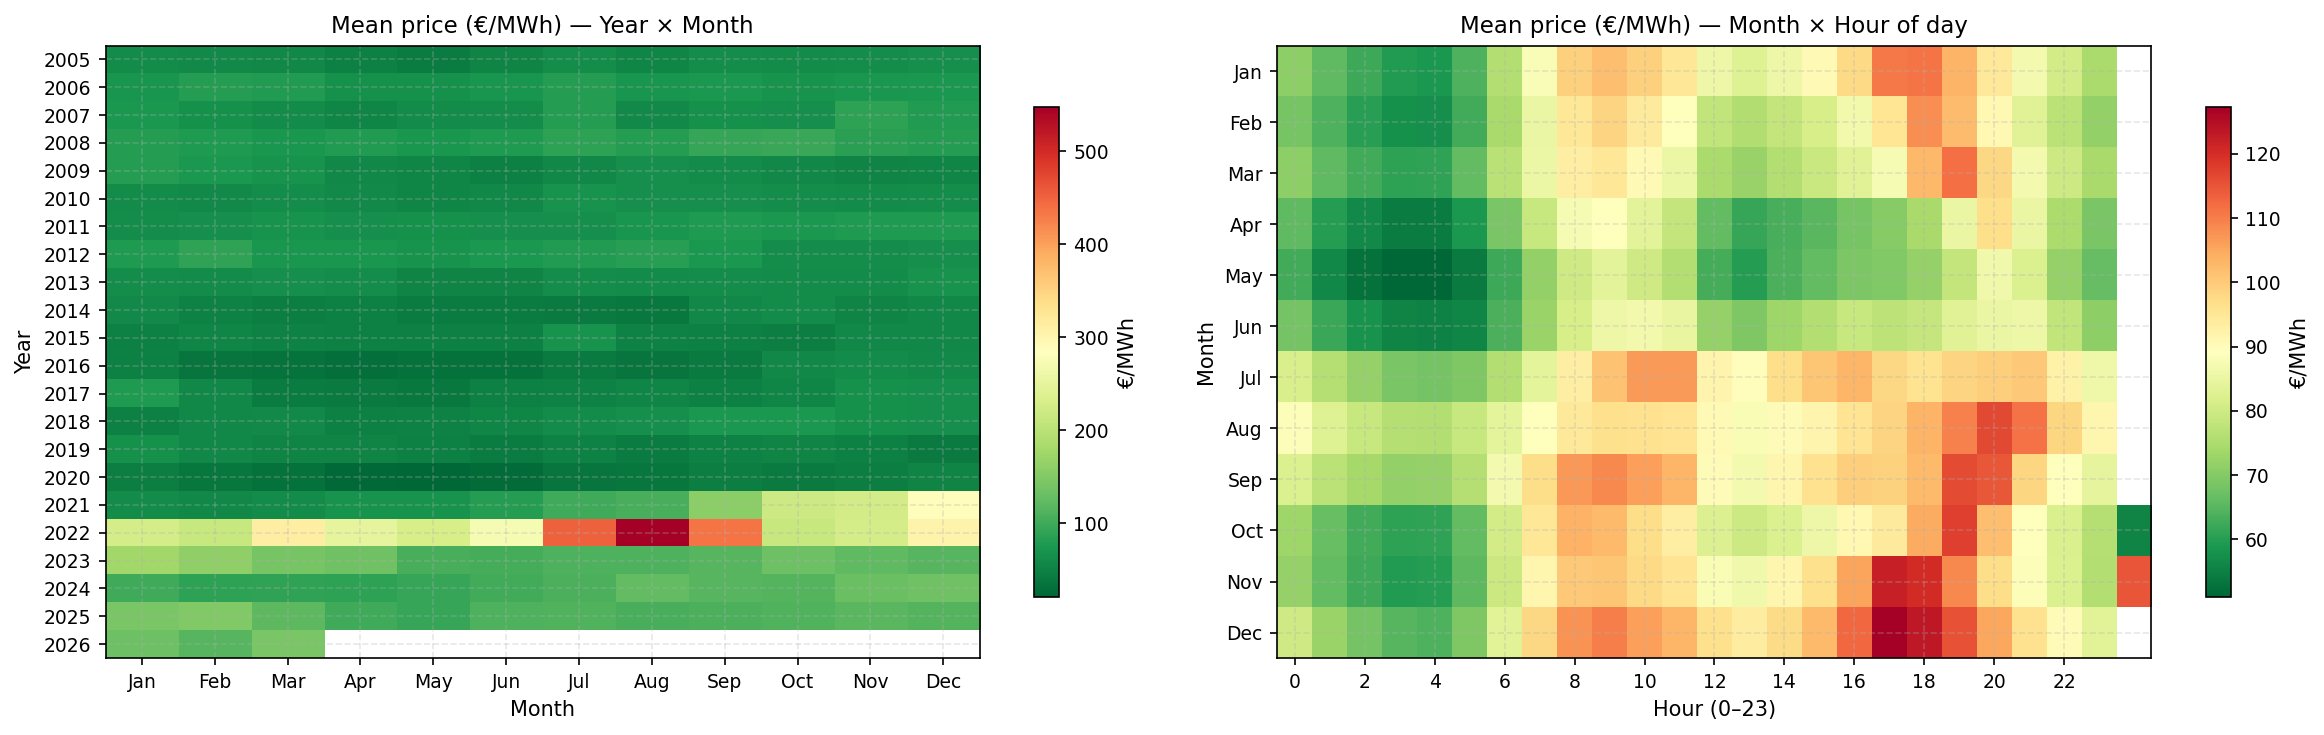

[Fig 3 saved]


In [14]:
# Pivot: year × month mean price
pivot_ym = df.pivot_table(values="price_NORD_EURMWh", index="year",
                           columns="month", aggfunc="mean")
pivot_ym.columns = MONTH_LABELS
 
# Pivot: month × hour mean price (average daily profile per month)
pivot_mh = df.pivot_table(values="price_NORD_EURMWh", index="month",
                           columns="hour", aggfunc="mean")
pivot_mh.index = MONTH_LABELS
 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
 
# Year × Month heatmap
ax = axes[0]
im = ax.imshow(pivot_ym.values, aspect="auto", cmap="RdYlGn_r", interpolation="nearest")
ax.set_xticks(range(12));   ax.set_xticklabels(MONTH_LABELS)
ax.set_yticks(range(len(pivot_ym)));  ax.set_yticklabels(pivot_ym.index)
ax.set_title("Mean price (€/MWh) — Year × Month")
ax.set_xlabel("Month"); ax.set_ylabel("Year")
plt.colorbar(im, ax=ax, label="€/MWh", shrink=0.8)
 
# Month × Hour heatmap
ax = axes[1]
im2 = ax.imshow(pivot_mh.values, aspect="auto", cmap="RdYlGn_r", interpolation="nearest")
ax.set_xticks(range(0, 24, 2));  ax.set_xticklabels(range(0, 24, 2))
ax.set_yticks(range(12));        ax.set_yticklabels(MONTH_LABELS)
ax.set_title("Mean price (€/MWh) — Month × Hour of day")
ax.set_xlabel("Hour (0–23)"); ax.set_ylabel("Month")
plt.colorbar(im2, ax=ax, label="€/MWh", shrink=0.8)
 
plt.tight_layout()
plt.show()
print("[Fig 3 saved]")

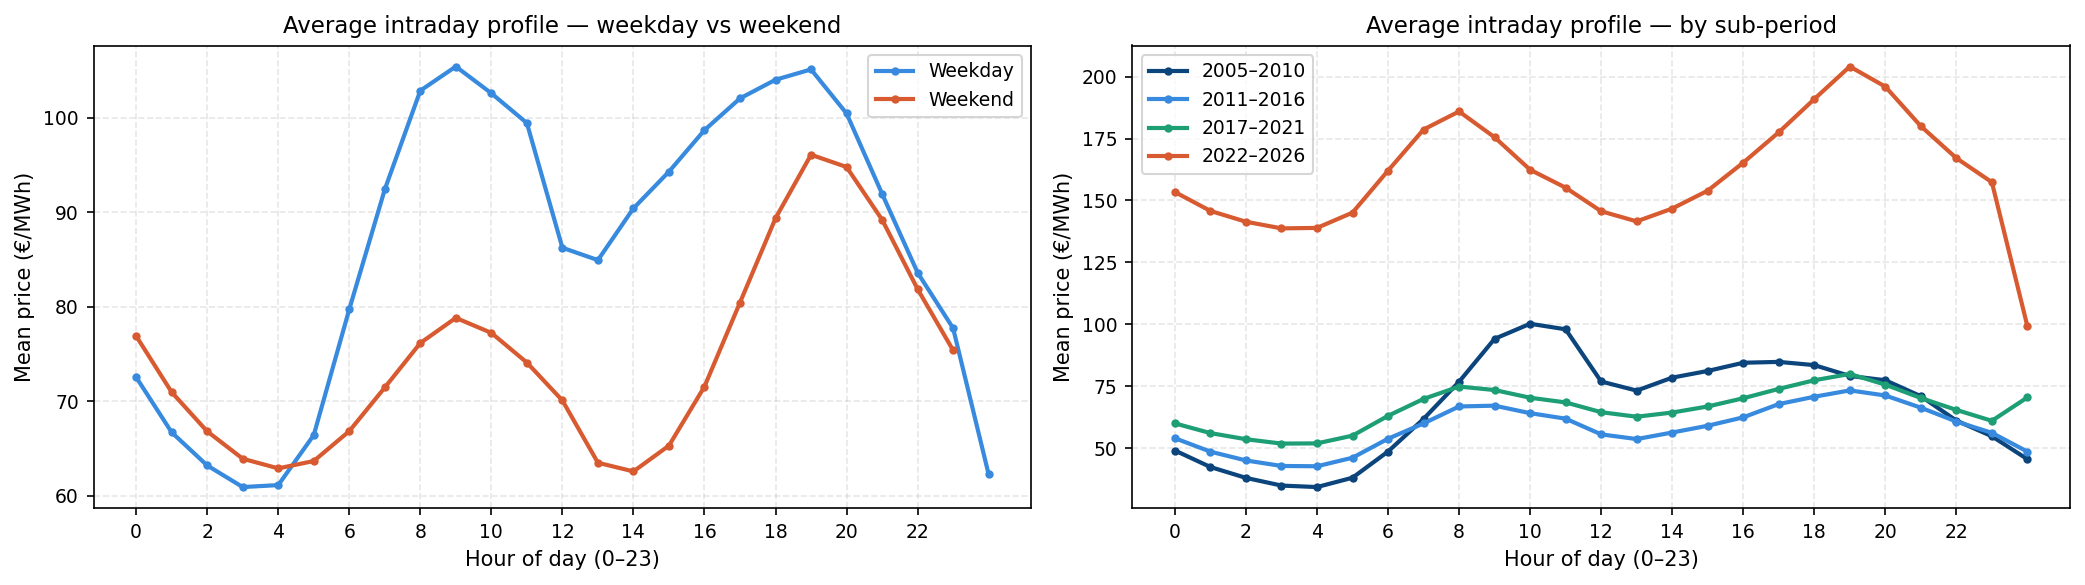

[Fig 4 saved]


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
 
# Average hourly profile — weekday vs weekend
ax = axes[0]
for is_we, label, color in [(False, "Weekday", "#378ADD"), (True, "Weekend", "#D85A30")]:
    profile = df[df["is_weekend"] == is_we].groupby("hour")["price_NORD_EURMWh"].mean()
    ax.plot(profile.index, profile.values, color=color, linewidth=2, label=label, marker="o", markersize=3)
ax.set_title("Average intraday profile — weekday vs weekend")
ax.set_xlabel("Hour of day (0–23)")
ax.set_ylabel("Mean price (€/MWh)")
ax.set_xticks(range(0, 24, 2))
ax.legend()
 
# Intraday profile by decade (2005–2010, 2011–2016, 2017–2021, 2022–2026)
ax = axes[1]
periods = [(2005,2010,"2005–2010","#0C447C"),
           (2011,2016,"2011–2016","#378ADD"),
           (2017,2021,"2017–2021","#1D9E75"),
           (2022,2026,"2022–2026","#D85A30")]
for y0, y1, label, color in periods:
    sub = df[(df["year"] >= y0) & (df["year"] <= y1)]
    profile = sub.groupby("hour")["price_NORD_EURMWh"].mean()
    ax.plot(profile.index, profile.values, color=color, linewidth=2, label=label, marker="o", markersize=3)
ax.set_title("Average intraday profile — by sub-period")
ax.set_xlabel("Hour of day (0–23)")
ax.set_ylabel("Mean price (€/MWh)")
ax.set_xticks(range(0, 24, 2))
ax.legend()
 
plt.tight_layout()
plt.show()
print("[Fig 4 saved]")
 

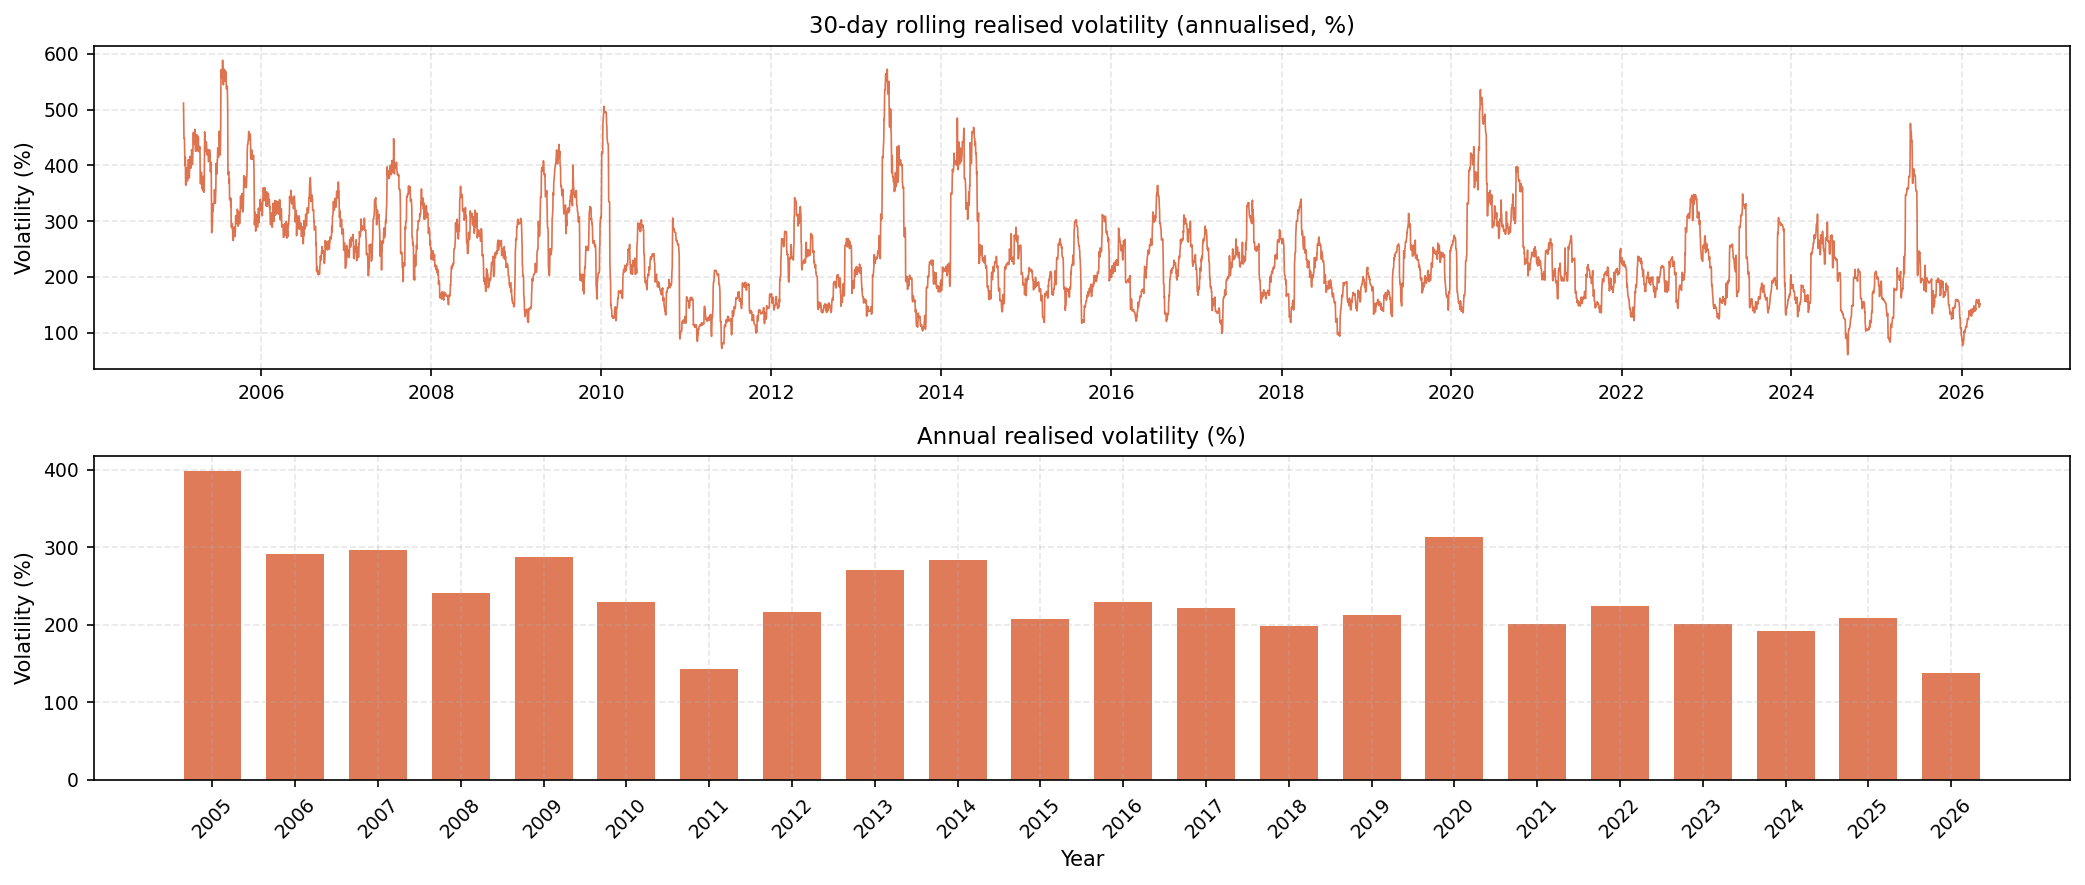

[Fig 5 saved]


In [16]:
# Daily log returns on daily mean price
df_vol = df_daily.copy().set_index("date")
df_vol["log_return"] = np.log(df_vol["price_daily_mean"] / df_vol["price_daily_mean"].shift(1))
df_vol["rolling_vol_30d"] = df_vol["log_return"].rolling(30).std() * np.sqrt(252)
 
# Annual realised volatility
ann_vol = df.copy()
ann_vol["log_ret"] = np.log(
    ann_vol.groupby("date")["price_NORD_EURMWh"].transform("mean") /
    ann_vol.groupby("date")["price_NORD_EURMWh"].transform("mean").shift(24)
)
ann_vol_yr = (ann_vol.groupby("year")["log_ret"]
              .std().apply(lambda s: s * np.sqrt(252)) * 100)
 
fig, axes = plt.subplots(2, 1, figsize=(14, 6))
 
ax = axes[0]
ax.plot(df_vol.index, df_vol["rolling_vol_30d"] * 100,
        color="#D85A30", linewidth=0.8, alpha=0.85)
ax.set_title("30-day rolling realised volatility (annualised, %)")
ax.set_ylabel("Volatility (%)")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
 
ax = axes[1]
ax.bar(ann_vol_yr.index, ann_vol_yr.values, color="#D85A30", alpha=0.8, width=0.7)
ax.set_title("Annual realised volatility (%)")
ax.set_ylabel("Volatility (%)")
ax.set_xlabel("Year")
ax.set_xticks(ann_vol_yr.index)
ax.tick_params(axis="x", rotation=45)
 
plt.tight_layout()
plt.show()
print("[Fig 5 saved]")

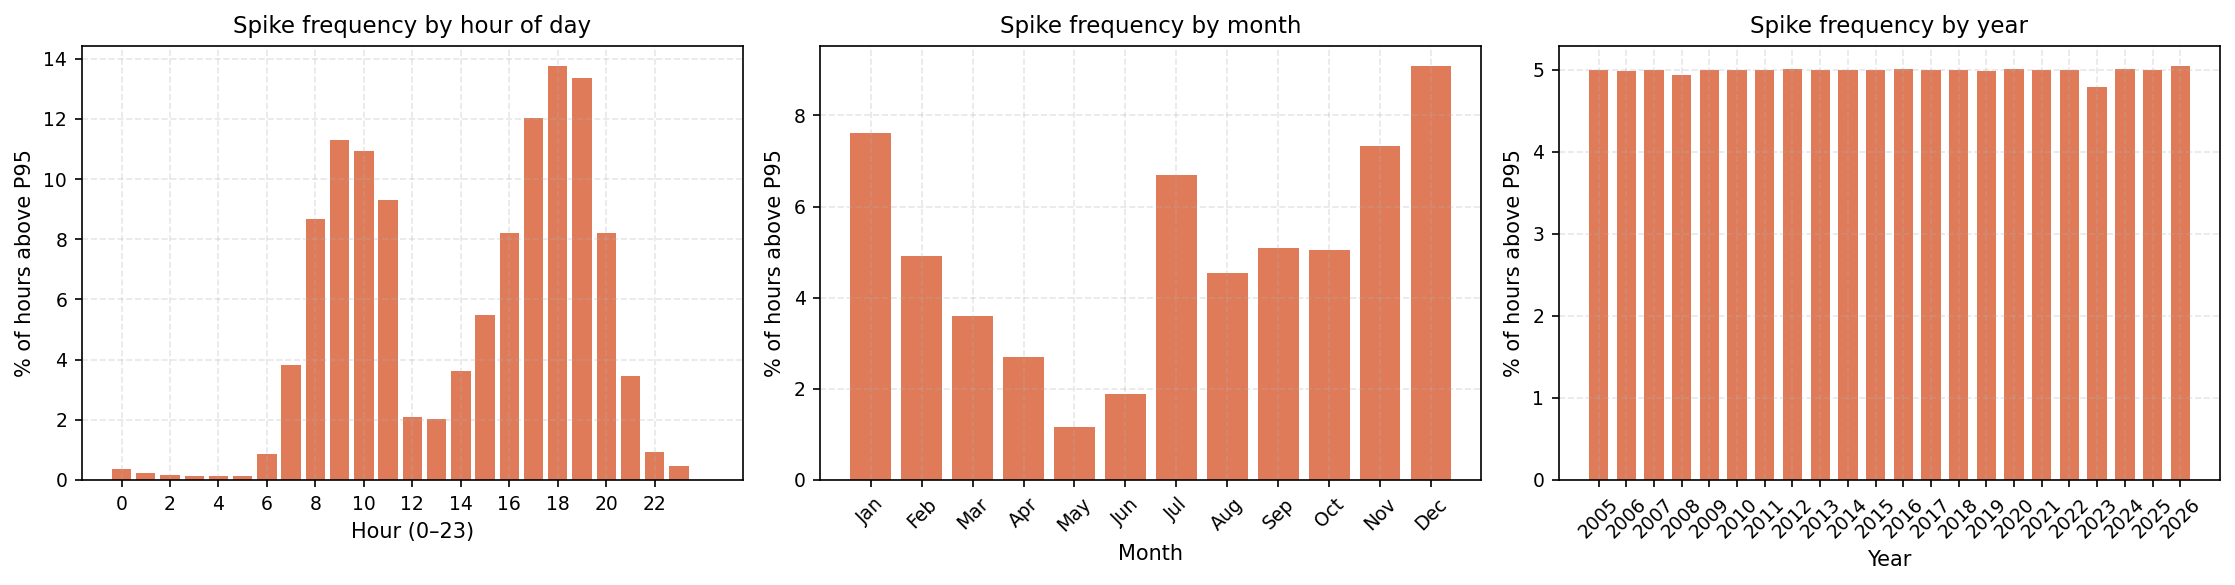

[Fig 6 saved]


In [17]:
# Define spike threshold: price > P95 within each year
df["p95_year"] = df.groupby("year")["price_NORD_EURMWh"].transform(lambda x: x.quantile(0.95))
df["is_spike"] = df["price_NORD_EURMWh"] > df["p95_year"]
 
spike_by_hour  = df.groupby("hour")["is_spike"].mean() * 100
spike_by_month = df.groupby("month")["is_spike"].mean() * 100
spike_by_year  = df.groupby("year")["is_spike"].mean() * 100
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
ax = axes[0]
ax.bar(spike_by_hour.index, spike_by_hour.values, color="#D85A30", alpha=0.8)
ax.set_title("Spike frequency by hour of day")
ax.set_xlabel("Hour (0–23)")
ax.set_ylabel("% of hours above P95")
ax.set_xticks(range(0, 24, 2))
 
ax = axes[1]
ax.bar(range(12), spike_by_month.values, color="#D85A30", alpha=0.8)
ax.set_xticks(range(12)); ax.set_xticklabels(MONTH_LABELS, rotation=45)
ax.set_title("Spike frequency by month")
ax.set_xlabel("Month")
ax.set_ylabel("% of hours above P95")
 
ax = axes[2]
ax.bar(spike_by_year.index, spike_by_year.values, color="#D85A30", alpha=0.8, width=0.7)
ax.set_title("Spike frequency by year")
ax.set_xlabel("Year")
ax.set_ylabel("% of hours above P95")
ax.set_xticks(spike_by_year.index)
ax.tick_params(axis="x", rotation=45)
 
plt.tight_layout()
plt.show()
print("[Fig 6 saved]")

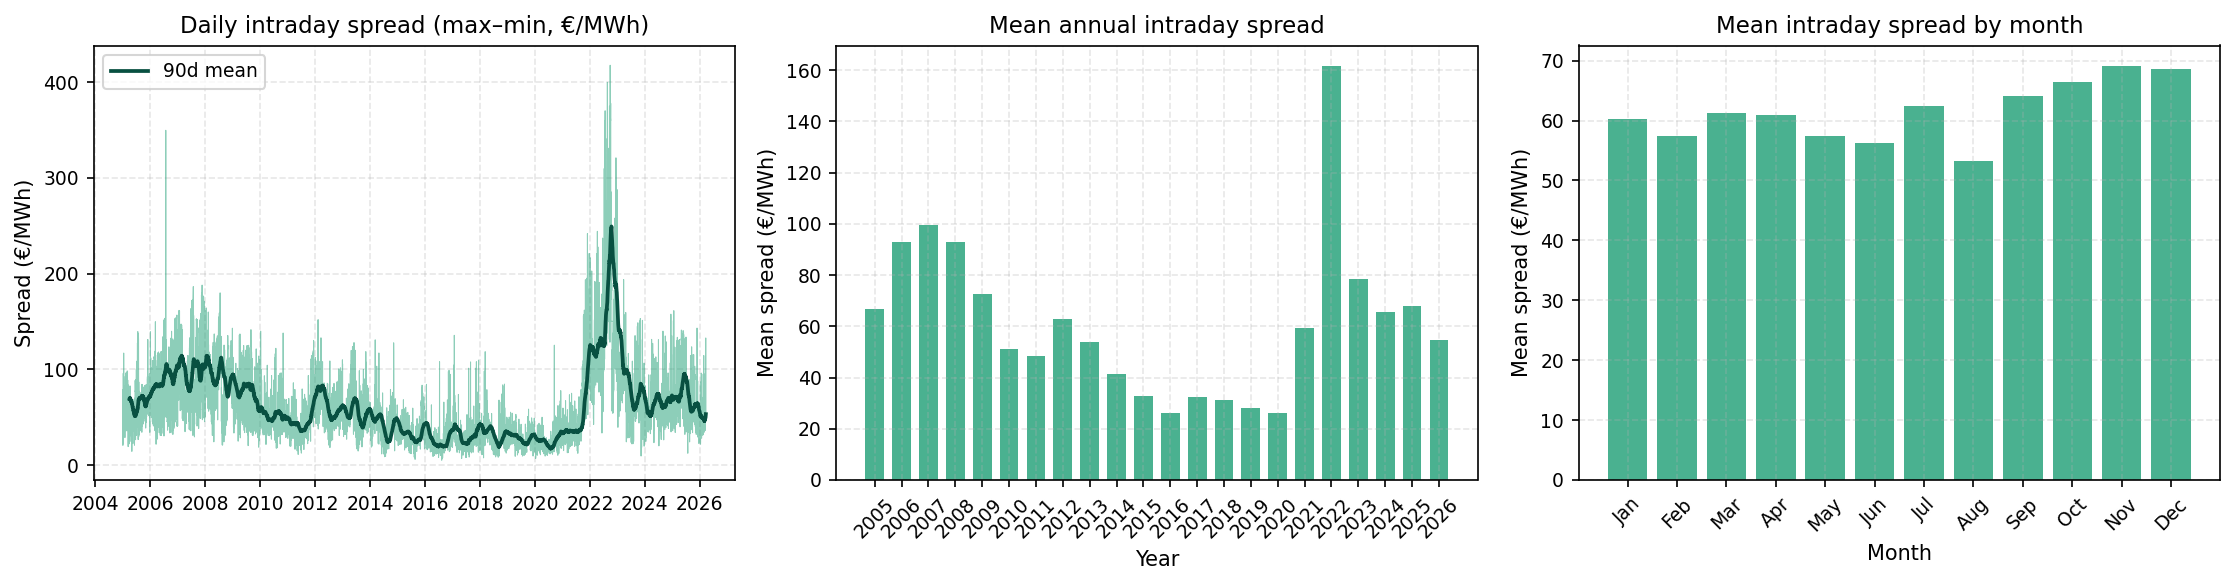

[Fig 7 saved]


In [18]:
# Daily spread = max(price) - min(price) within each day
df_spread = df.groupby("date")["price_NORD_EURMWh"].agg(
    daily_max="max", daily_min="min"
).reset_index()
df_spread["daily_spread"] = df_spread["daily_max"] - df_spread["daily_min"]
df_spread["year"] = pd.to_datetime(df_spread["date"]).dt.year
df_spread["month"] = pd.to_datetime(df_spread["date"]).dt.month
 
# Annual mean spread
spread_annual = df_spread.groupby("year")["daily_spread"].mean()
 
# Monthly mean spread (all years)
spread_monthly = df_spread.groupby("month")["daily_spread"].mean()
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
# Time series of daily spread
ax = axes[0]
ax.plot(df_spread["date"], df_spread["daily_spread"],
        color="#1D9E75", linewidth=0.5, alpha=0.5)
roll_spread = df_spread.set_index("date")["daily_spread"].rolling(90).mean()
ax.plot(roll_spread.index, roll_spread.values, color="#085041", linewidth=1.8, label="90d mean")
ax.set_title("Daily intraday spread (max–min, €/MWh)")
ax.set_ylabel("Spread (€/MWh)")
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
 
# Annual mean spread
ax = axes[1]
ax.bar(spread_annual.index, spread_annual.values, color="#1D9E75", alpha=0.8, width=0.7)
ax.set_title("Mean annual intraday spread")
ax.set_xlabel("Year")
ax.set_ylabel("Mean spread (€/MWh)")
ax.set_xticks(spread_annual.index)
ax.tick_params(axis="x", rotation=45)
 
# Monthly mean spread
ax = axes[2]
ax.bar(range(12), spread_monthly.values, color="#1D9E75", alpha=0.8)
ax.set_xticks(range(12)); ax.set_xticklabels(MONTH_LABELS, rotation=45)
ax.set_title("Mean intraday spread by month")
ax.set_xlabel("Month")
ax.set_ylabel("Mean spread (€/MWh)")
 
plt.tight_layout()
plt.show()
print("[Fig 7 saved]")

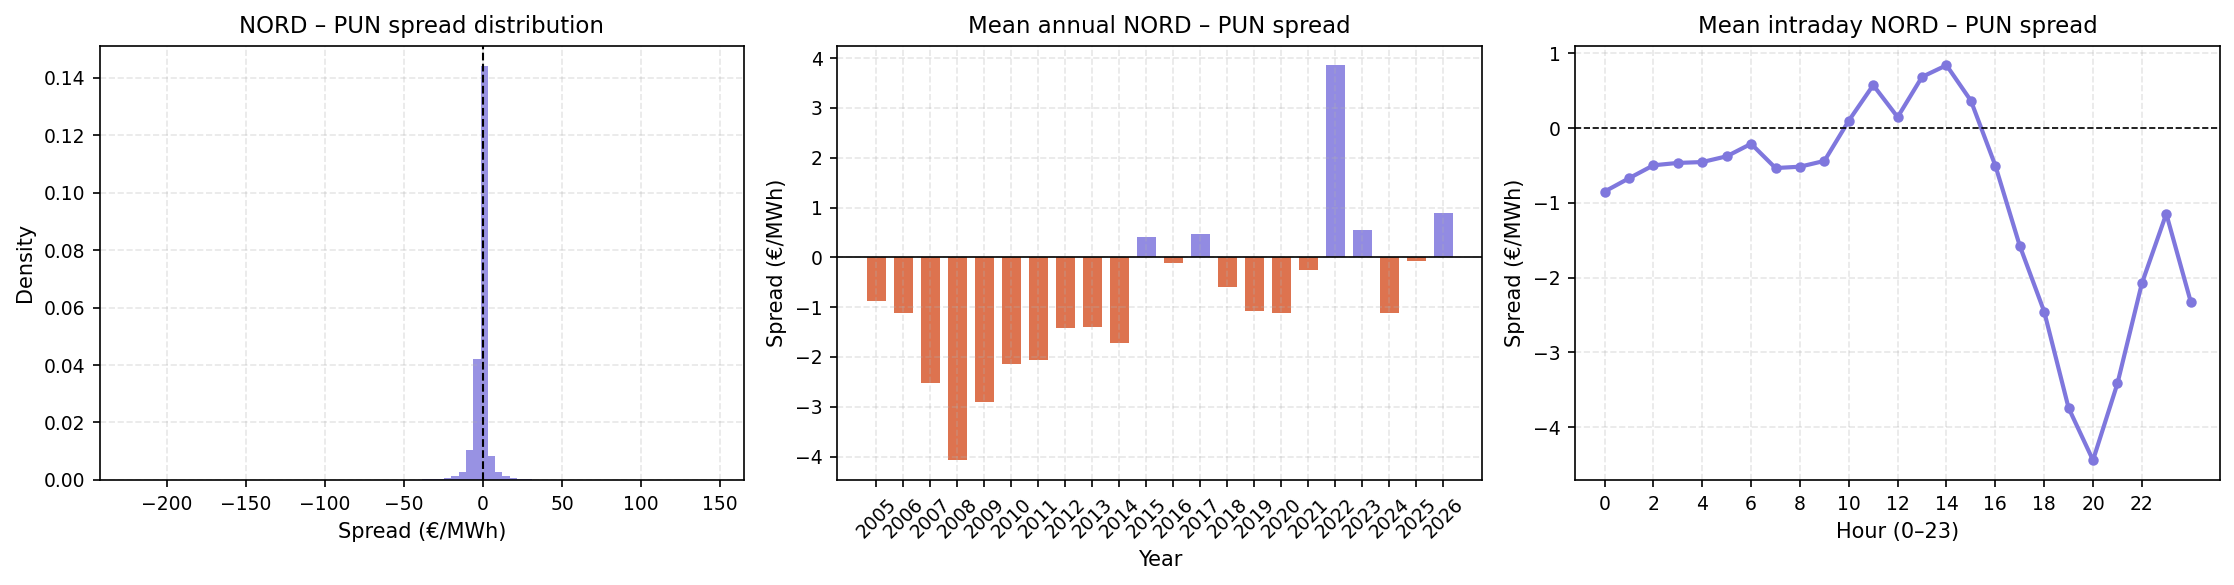

[Fig 8 saved]


In [19]:
df["zonal_spread"] = df["price_NORD_EURMWh"] - df["price_PUN_EURMWh"]
 
zonal_annual = df.groupby("year")["zonal_spread"].mean()
zonal_hourly = df.groupby("hour")["zonal_spread"].mean()
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
ax = axes[0]
ax.hist(df["zonal_spread"].dropna(), bins=80, color="#7F77DD", alpha=0.8, edgecolor="none", density=True)
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("NORD – PUN spread distribution")
ax.set_xlabel("Spread (€/MWh)")
ax.set_ylabel("Density")
 
ax = axes[1]
colors_z = ["#7F77DD" if v >= 0 else "#D85A30" for v in zonal_annual.values]
ax.bar(zonal_annual.index, zonal_annual.values, color=colors_z, alpha=0.85, width=0.7)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Mean annual NORD – PUN spread")
ax.set_xlabel("Year")
ax.set_ylabel("Spread (€/MWh)")
ax.set_xticks(zonal_annual.index)
ax.tick_params(axis="x", rotation=45)
 
ax = axes[2]
ax.plot(zonal_hourly.index, zonal_hourly.values,
        color="#7F77DD", linewidth=2, marker="o", markersize=4)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Mean intraday NORD – PUN spread")
ax.set_xlabel("Hour (0–23)")
ax.set_ylabel("Spread (€/MWh)")
ax.set_xticks(range(0, 24, 2))
 
plt.tight_layout()
plt.show()
print("[Fig 8 saved]")

In [20]:
summary = df.groupby("year")["price_NORD_EURMWh"].agg(
    Mean="mean", Std="std", Min="min",
    P10=lambda x: x.quantile(0.10),
    P25=lambda x: x.quantile(0.25),
    Median="median",
    P75=lambda x: x.quantile(0.75),
    P90=lambda x: x.quantile(0.90),
    Max="max",
    Spikes=lambda x: (x > x.quantile(0.95)).sum()
).round(2)
 
print("\nAnnual summary statistics — NORD Day-Ahead Price (€/MWh)")
print(summary.to_string())
print("\n[SAVED] GME_NORD_annual_summary.csv")


Annual summary statistics — NORD Day-Ahead Price (€/MWh)
        Mean     Std    Min     P10     P25  Median     P75     P90     Max  Spikes
year                                                                               
2005   57.66   27.78   0.00   25.75   35.22   50.60   77.69  100.11  170.61     438
2006   73.63   33.71   3.00   39.50   49.70   64.49   89.95  120.18  400.00     436
2007   68.48   35.99  15.00   27.93   45.08   61.63   84.90  113.33  239.57     438
2008   82.92   31.59  20.50   41.89   62.50   79.92  100.00  125.16  209.98     433
2009   60.83   25.81   9.00   28.00   45.00   56.56   76.00   95.00  169.01     438
2010   61.98   17.56  10.00   41.98   51.90   61.70   69.90   80.05  189.01     437
2011   70.18   15.67  10.00   51.09   61.54   69.31   78.54   87.73  165.07     438
2012   74.05   21.53  13.00   47.03   63.00   73.51   84.69   95.29  224.00     440
2013   61.59   17.37   0.00   38.00   54.98   63.00   70.01   79.00  150.04     438
2014   50.35   14.